# Gradient Boosting

## Concepts Learned

1. Gradient Boost(Overall)
    * Works on idea that doing a bunch of smalls steps will achieve your goal. 
    * An esemble model that uses many Deciesion Trees
    * One of the best Machine Learning Models
2. Gradient Boost Regression
    * Get the average of your outcomes and create your first tree from it. This tree will have only 1 node, the average of your target, and will serve as a base.
    * Get the resudials of actual values - predicted(Your average for now)
    * Create a second tree that predicts the resduials. If a leaf has more than 1 value, find the average of all values in a leaf.
    * Prediction works like this its base value(Average) + learning rate * sum(all Tree outcomes)
    * Predict your dataset and find the resudials.
    * Repeat until your model doesn't improve, or you meet a preset stopping conditon.
3. Gradient Boost Classification
    * Works Similariy to Gradient Boost Regression, however, classes are converted to binary and we are predicting probality instead.
    * For 3+ classes, Multinomal Softmax is used.
4. SGD 
    * Normal Gradient Descent calcautes the loss of each point of data. This is really bad, if there are 1000 features and a millino data points, as you would need calcaute 1 billion things every step. 
    * SGD fixes this. Instead of calcauting the loss of each point, chose a random point and calcuate only the loss of that. This works really well. 
    * Normal GD is a like smart dude who has be perfect - He will take the right path, but we will take a long time and lots of resources to do so.
    * SGD is a like drunk man who stubbling forward - He will reach his destinition eventually, but he will get lost or make mistakes.
    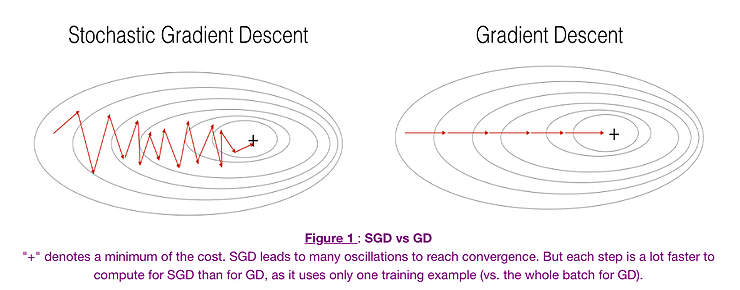

In [1]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from ucimlrepo import fetch_ucirepo 
heart_disease = fetch_ucirepo(id=45) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
y = (y > 0).astype(int)
y = np.squeeze(y)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, shuffle=True, test_size=0.2)

In [4]:
model = HistGradientBoostingClassifier(learning_rate=0.1, l2_regularization=1, early_stopping=True)


In [13]:
print(np.mean(cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy'))*100)

80.19999999999999


In [7]:
model.fit(X_train, y_train)

,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",True
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to 

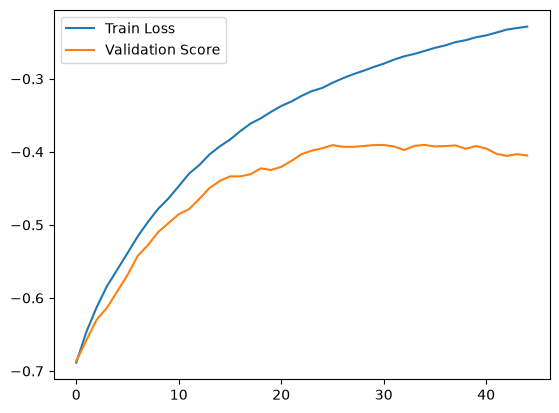

In [8]:
plt.plot(model.train_score_, label = "Train Loss")
plt.plot(model.validation_score_, label = "Validation Score")
plt.legend()
plt.show()

In [9]:
y_pred= model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"f1 Score: {f1_score(y_test, y_pred)}")

Accuracy: 0.8852459016393442
f1 Score: 0.8771929824561403


Performs 8% better than randonforest classifer on the samedataset. Far faster to train as well. Model took less than a second to fit, while RandomForestClassifer took over a minute for worse performance.